# Advanced: Water Clouds

In this notebook, we'll add parametric water clouds to our simulations using the `params` mechanism. This is one of the simplest ways to include clouds — by specifying a cloud water content file directly in the simulation call.

In [1]:
import pyradtran  # Registers the .pyradtran xarray accessor
from pyradtran import Var
from pyradtran import load_config
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

# Suppress pyradtran log output for cleaner notebook cells
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

## Setup: Define the Scene

We create a simple single-timestep `xr.Dataset` representing a mid-latitude location on a spring day. The dataset includes coordinates for time, latitude, longitude, and altitude, as well as a surface temperature variable.

In [2]:
# ── Solar config ─────────────────────────────────────────────────────────────
cfg_solar = load_config()
cfg_solar.simulation_defaults.rte_solver           = "disort"
cfg_solar.simulation_defaults.mol_abs_param        = "reptran per_nm"
cfg_solar.simulation_defaults.source               = "solar"
cfg_solar.simulation_defaults.wavelength_nm        = [400, 3200]
cfg_solar.simulation_defaults.integrate_wavelength = True
cfg_solar.simulation_defaults.output_columns       = ["zout", "lambda", "sza", "edir", "eglo", "edn", "eup", "enet", "albedo"]
cfg_solar.execution.max_workers                    = 16
cfg_solar.execution.cleanup_temp_files             = False
solar_config_path = Path("config/cloud_solar.yaml")
cfg_solar.to_yaml(solar_config_path)

# ── Thermal config ────────────────────────────────────────────────────────────
cfg_thermal = load_config()
cfg_thermal.simulation_defaults.rte_solver           = "disort"
cfg_thermal.simulation_defaults.mol_abs_param        = "reptran medium"
cfg_thermal.simulation_defaults.source               = "thermal"
cfg_thermal.simulation_defaults.wavelength_nm        = [4500, 42000]
cfg_thermal.simulation_defaults.integrate_wavelength = True
cfg_thermal.simulation_defaults.output_columns       = ["zout", "lambda", "sza", "edir", "eglo", "edn", "eup", "enet", "albedo"]
cfg_thermal.execution.max_workers                    = 16
cfg_thermal.execution.cleanup_temp_files             = False
thermal_config_path = Path("config/cloud_thermal.yaml")
cfg_thermal.to_yaml(thermal_config_path)

print(f"Solar config:   {solar_config_path}")
print(f"Thermal config: {thermal_config_path}")

# ── Input dataset ─────────────────────────────────────────────────────────────
N_timesteps = 1

ds = xr.Dataset(
    coords={
        'time'      : pd.date_range('2025-04-04T12:00:00', periods=N_timesteps, freq='s'),
        'latitude'  : ('time', [51.3406321] * N_timesteps),
        'longitude' : ('time', [12.3747329] * N_timesteps),
        'altitude'  : ('altitude', np.arange(0, 10, 0.5)),
    },
    data_vars={
        'surface_temperature': ('time', [290] * N_timesteps),  # Kelvin
    }
)

ds

2026-04-20 11:26:36,116 - pyradtran.config - INFO - Configuration written to config/cloud_solar.yaml
2026-04-20 11:26:36,119 - pyradtran.config - INFO - Configuration written to config/cloud_thermal.yaml


Solar config:   config/cloud_solar.yaml
Thermal config: config/cloud_thermal.yaml


<xarray.Dataset> Size: 192B
Dimensions:              (time: 1, altitude: 20)
Coordinates:
  * time                 (time) datetime64[ns] 8B 2025-04-04T12:00:00
    latitude             (time) float64 8B 51.34
    longitude            (time) float64 8B 12.37
  * altitude             (altitude) float64 160B 0.0 0.5 1.0 1.5 ... 8.5 9.0 9.5
Data variables:
    surface_temperature  (time) int64 8B 290

## Define a Water Cloud

A water cloud in libRadtran is specified as a simple text file with columns for altitude (km), liquid water content (LWC, g/m³), and effective droplet radius (R_eff, µm):

```
#      z     LWC    R_eff
#     (km)  (g/m³)  (µm)
      4.000   5.0    15.0
      3.000   3.0    12.0
      2.000   0.0    10.0
```

This defines a cloud layer between 2 and 4 km with increasing LWC and droplet size toward the cloud top. Let's write this to a file at `work/water_cloud.wc`.

In [3]:
wc_content = """
#      z     LWC    R_eff
#     (km)  (g/m^3) (um)  
      4.000   5.0    15.0 
      3.000   3.0    12.0  
      2.000   0.0    10.0  
"""

wc_file_path = Path('work/water_cloud.wc')
wc_file_path.parent.mkdir(parents=True, exist_ok=True)
wc_file_path.write_text(wc_content)

print(f"Water cloud definition written to {wc_file_path}")

Water cloud definition written to work/water_cloud.wc


## Run Solar and Thermal Simulations with `params`

The `params` argument lets you inject or override any libRadtran input parameter at runtime. Here, we use it to set the `wc_file 1D` parameter, which tells libRadtran to read a one-dimensional water cloud profile from the file we just created.

This is equivalent to adding the line `wc_file 1D work/water_cloud.wc` to the libRadtran input file. Any parameter from the [libRadtran documentation](http://www.libradtran.org/doku.php) can be overridden this way.

In [4]:
ds_sim_solar = ds.pyradtran.run(
    config_path=solar_config_path,
    return_dataset=True,
    save_to_file=True,
    params={
        'sur_temperature': Var('surface_temperature'),
        'wc_file 1D' : 'work/water_cloud.wc',
    },
    show_progress=False,
)

ds_sim_thermal = ds.pyradtran.run(
    config_path=thermal_config_path,
    return_dataset=True,
    save_to_file=True,
    params={
        'sur_temperature': Var('surface_temperature'),
        'wc_file 1D' : 'work/water_cloud.wc',
    },
    show_progress=False,
)

## Visualize the Irradiance Profiles

We plot the net solar and thermal irradiance profiles as a function of altitude. The gray shaded region marks the cloud layer (2–4 km).

Text(0.5, 1.0, '')

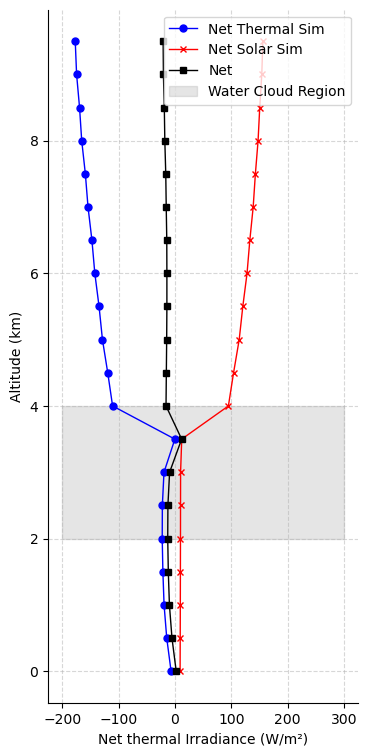

In [5]:
fig, ax = plt.subplots(figsize=(4, 9))

ds_sim_thermal.enet.sel(time='2025-04-04T12:00:00').plot(y='altitude', ax=ax, marker='o', color='blue', label='Net Thermal Sim', lw=1, markersize=5)
(ds_sim_solar.enet / 1e3).sel(time='2025-04-04T12:00:00').plot(y='altitude', ax=ax, marker='x', color='red', label='Net Solar Sim', lw=1, markersize=5)
net = ds_sim_solar.enet.sel(time='2025-04-04T12:00:00').values / 1e3 + ds_sim_thermal.enet.sel(time='2025-04-04T12:00:00').values
ax.plot(net, ds_sim_solar.altitude, color='black', label='Net', lw=1, marker='s', markersize=5)
# shade the region where the water cloud is present
ax.fill_betweenx(np.arange(2, 5), -200, 300, color='gray', alpha=0.2, label='Water Cloud Region')
ax.set_xlabel('Net thermal Irradiance (W/m²)')
ax.set_ylabel('Altitude (km)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title('')



### Interpretation

The plot above shows the vertical profiles of net irradiance for the cloudy atmosphere:

- **Net solar irradiance** (red) decreases sharply within the cloud layer as sunlight is scattered and absorbed by cloud droplets.
- **Net thermal irradiance** (blue) shows a strong gradient at the cloud boundaries — the cloud top emits strongly to space, while the cloud base receives thermal emission from below.
- **Total net irradiance** (black) combines both components. Notice the strong radiative cooling at cloud top and warming at cloud base, which is characteristic of optically thick water clouds.

## Other methdods to include clouds

While `params` is the simplest way to include clouds, pyRadtran also supports more complex cloud representations:

In [ ]:
from pyradtran.clouds import CloudLayer, CloudFileWriter

simple_cloud = CloudLayer(
    z_bottom_km=2.0,
    z_top_km=4.0,
    lwc_g_m3=10.0,
)

cloud_file_writer = CloudFileWriter()


TypeError: 'CloudFileWriter' object is not callable